# SHL Audio Grammar Scoring: frozen features + Ridge/LightGBM ensemble

**Task.** Predict a continuous grammar MOS (1-5) from 45-60 s spoken answers. Only 769 labelled clips, so no end-to-end fine-tuning. Every neural net below is frozen and used as a feature extractor; learning happens in cheap tabular models.

**Pipeline**
1. **Audio prep.** 16 kHz mono, edge silence trimmed (`top_db=30`).
2. **Prosody / fluency (librosa, ~80 feats).** Speech vs. pause timing (silences >= 250 ms: ratio, count, mean/max), onset-based speaking and articulation rate, rhythm (inter-onset interval stats), ZCR / spectral centroid / rolloff / bandwidth / RMS stats, MFCC mean+std, YIN pitch stats.
3. **Acoustic embedding.** `wav2vec2-base-960h`, mean-pooled frames from layer 8 and the last layer (1536-d), run on 20 s windows.
4. **ASR.** Whisper (`small` on GPU, `base` on CPU) transcribes every clip.
5. **Text embedding.** `deberta-v3-base`, attention-masked mean pooling (768-d).
6. **Lexical feats.** Word count, TTR, avg sentence length, char length, filler and repeat counts, words/sec.
7. **Caching.** Every stage plus the final `X_train.npy` / `X_test.npy` is cached, so re-runs skip all embedding work.

**Validation / model**
- `KFold(5, shuffle=True, random_state=42)`, same folds for every model.
- **Ridge** on standardised full feature matrix (alpha swept on OOF RMSE).
- **LightGBM** on hand-crafted feats + per-fold PCA(48) of each embedding block (PCA fit on the train fold only).
- Equal-weight blend; test predictions averaged over the 5 fold models x 2 model types, clipped to [0, 5].

**Reported:** training RMSE (in-sample), OOF RMSE, Pearson r, prediction-vs-truth scatter, LightGBM gain importance, `submission.csv`.

**Caveat.** Whisper tends to "clean up" disfluencies and grammar slips, so some grammar signal is lost in the transcript. That is why the raw-audio embedding and prosody features sit next to the text features.

In [1]:
%pip install -q kagglehub librosa lightgbm sentencepiece tiktoken transformers joblib tqdm

In [2]:
import gc, json, random, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import librosa
import kagglehub
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from scipy.stats import pearsonr
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from transformers import AutoFeatureExtractor, AutoModel, AutoTokenizer, Wav2Vec2Model, pipeline

warnings.filterwarnings('ignore')

SEED = 42
SR = 16000
TOP_DB = 30
PAUSE_MIN = 0.25                       # sec, pause threshold
HOP = 256
CLIP = (0.0, 5.0)
W2V = 'facebook/wav2vec2-base-960h'
DEB = 'microsoft/deberta-v3-base'
W2V_LAYERS = (8, -1)                   # mid + last layer
W2V_DIM, DEB_DIM = 768 * len(W2V_LAYERS), 768
PCA_K = 48

DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
WHISPER = 'openai/whisper-small' if DEV == 'cuda' else 'openai/whisper-base'

OUT = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
CACHE = OUT / 'cache'
CACHE.mkdir(exist_ok=True, parents=True)


def seed_all(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)


def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))


def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


seed_all()
print('device:', DEV, '| whisper:', WHISPER)

device: cuda | whisper: openai/whisper-small


In [3]:
import kagglehub

# This will prompt you to enter your Kaggle username and API token.
# You can generate a new token from your Kaggle account settings (Settings -> Create New Token)
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [5]:
# needs kaggle creds + joined competition (kagglehub.login() if prompted)
import kagglehub

# Download latest version
path = kagglehub.competition_download('shl-hiring-assessment-2026')
print("Path to competition files:", path)

ROOT = next((p.parent for p in Path(path).rglob('train.csv') if (p.parent / 'train').is_dir()), None)
assert ROOT is not None, f'train.csv + train/ not found under {path}'

train_df = pd.read_csv(ROOT / 'train.csv')
test_df = pd.read_csv(ROOT / 'test.csv')
sample_sub = pd.read_csv(ROOT / 'sample_submission.csv')


def wav_path(split, name):
    p = ROOT / split / name
    if not p.exists():
        p = ROOT / split / f'{name}.wav'
    return str(p)


train_paths = [wav_path('train', f) for f in train_df.filename]
test_paths = [wav_path('test', f) for f in test_df.filename]
all_paths = train_paths + test_paths
assert all(Path(p).exists() for p in all_paths), 'missing wav files'

y = train_df['label'].values.astype(np.float64)
print(train_df.shape, test_df.shape, sample_sub.shape)
print(train_df['label'].describe().round(3).to_dict())

100%|██████████| 1.22G/1.22G [00:16<00:00, 77.5MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/shl-hiring-assessment-2026
(769, 2) (216, 2) (204, 2)
{'count': 769.0, 'mean': 3.313, 'std': 1.239, 'min': 0.0, '25%': 2.5, '50%': 3.0, '75%': 4.0, 'max': 5.0}


In [6]:
# ---- audio + prosody features ----
def trim_audio(y):
    yt, _ = librosa.effects.trim(y, top_db=TOP_DB)  # strip edge silence
    return yt if len(yt) > SR // 2 else y


def load_audio(path):
    y, _ = librosa.load(path, sr=SR, mono=True)  # 16khz resample
    return trim_audio(y)


def _ms(prefix, a):
    return {f'{prefix}_mean': a.mean(), f'{prefix}_std': a.std()}


def acoustic_dict(y_raw):
    y = trim_audio(y_raw)
    dur = len(y) / SR

    # speech chunks -> pauses (>250ms gaps)
    iv = librosa.effects.split(y, top_db=TOP_DB, frame_length=1024, hop_length=HOP)
    speech = (iv[:, 1] - iv[:, 0]).sum() / SR if len(iv) else 0.0
    gaps = (iv[1:, 0] - iv[:-1, 1]) / SR if len(iv) > 1 else np.zeros(0)
    pz = gaps[gaps >= PAUSE_MIN]

    d = {
        'dur_raw': len(y_raw) / SR, 'dur_trim': dur, 'speech_time': speech,
        'speech_ratio': speech / dur, 'n_segments': len(iv),
        'pause_ratio': pz.sum() / dur, 'n_pauses': len(pz), 'pauses_per_sec': len(pz) / dur,
        'pause_mean': pz.mean() if len(pz) else 0.0,
        'pause_max': pz.max() if len(pz) else 0.0,
        'pause_std': pz.std() if len(pz) else 0.0,
    }

    # speaking rate proxy: onsets ~ syllable nuclei
    on = librosa.onset.onset_detect(y=y, sr=SR, hop_length=HOP, units='time')
    ioi = np.diff(on) if len(on) > 1 else np.zeros(1)
    d.update({
        'onset_rate': len(on) / dur, 'artic_rate': len(on) / max(speech, 1e-3),
        'ioi_mean': ioi.mean(), 'ioi_std': ioi.std(),
    })

    # spectral / energy stats
    kw = dict(n_fft=1024, hop_length=HOP)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=1024, hop_length=HOP)[0]
    cen = librosa.feature.spectral_centroid(y=y, sr=SR, **kw)[0]
    rol = librosa.feature.spectral_rolloff(y=y, sr=SR, **kw)[0]
    bw = librosa.feature.spectral_bandwidth(y=y, sr=SR, **kw)[0]
    rms = librosa.feature.rms(y=y, frame_length=1024, hop_length=HOP)[0]
    for k, v in [('zcr', zcr), ('centroid', cen), ('rolloff', rol), ('bandwidth', bw), ('rms', rms)]:
        d.update(_ms(k, v))

    mf = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=13, n_mels=40, **kw)
    for i, (m, s) in enumerate(zip(mf.mean(1), mf.std(1))):
        d[f'mfcc{i}_mean'], d[f'mfcc{i}_std'] = m, s

    # pitch on loud frames only
    f0 = librosa.yin(y, fmin=65, fmax=400, sr=SR, frame_length=1024, hop_length=HOP)
    n = min(len(f0), len(rms))
    f0v = f0[:n][rms[:n] > 0.05 * rms.max()]
    if len(f0v) > 10:
        d.update({'f0_mean': f0v.mean(), 'f0_std': f0v.std(),
                  'f0_range': np.percentile(f0v, 90) - np.percentile(f0v, 10)})
    else:
        d.update({'f0_mean': 0.0, 'f0_std': 0.0, 'f0_range': 0.0})

    return {k: float(v) for k, v in d.items()}


AC_NAMES = list(acoustic_dict(np.random.RandomState(0).randn(SR * 4).astype(np.float32) * 0.1))


def acoustic_feats(path):
    y, _ = librosa.load(path, sr=SR, mono=True)
    return acoustic_dict(y)


def acoustic_matrix(paths):
    rows = Parallel(n_jobs=-1)(delayed(acoustic_feats)(p) for p in tqdm(paths, desc='prosody'))
    return np.array([[r[k] for k in AC_NAMES] for r in rows], dtype=np.float32)


def cached(name, fn):
    f = CACHE / name
    if f.exists():
        return np.load(f)
    arr = fn()
    np.save(f, arr)
    return arr


print(len(AC_NAMES), 'acoustic feats')

54 acoustic feats


In [7]:
# ---- wav2vec2: mean-pooled frame embeddings ----
def w2v_matrix(paths, win=20 * SR):
    fe = AutoFeatureExtractor.from_pretrained(W2V)
    model = Wav2Vec2Model.from_pretrained(W2V).to(DEV).eval()
    out = []
    for p in tqdm(paths, desc='wav2vec2'):
        y = load_audio(p)
        frames = {l: [] for l in W2V_LAYERS}
        for s in range(0, len(y), win):
            c = y[s:s + win]
            if s > 0 and len(c) < SR // 2:
                continue  # skip tiny tail
            x = fe(c, sampling_rate=SR, return_tensors='pt').input_values.to(DEV)
            with torch.no_grad():
                hs = model(x, output_hidden_states=True).hidden_states
            for l in W2V_LAYERS:
                frames[l].append(hs[l][0].float())
        out.append(torch.cat([torch.cat(frames[l]).mean(0) for l in W2V_LAYERS]).cpu().numpy())
    del model
    free_gpu()
    return np.stack(out).astype(np.float32)

In [8]:
# ---- whisper transcripts (cached json) ----
def transcribe(paths, bs=8):
    f = CACHE / 'transcripts_all.json'
    if f.exists():
        return json.loads(f.read_text())
    asr = pipeline('automatic-speech-recognition', model=WHISPER, device=DEV, chunk_length_s=30)
    gen = {'language': 'en', 'task': 'transcribe'}
    txt = []
    for i in tqdm(range(0, len(paths), bs), desc='whisper'):
        batch = [{'raw': load_audio(p), 'sampling_rate': SR} for p in paths[i:i + bs]]
        res = asr(batch, batch_size=bs, generate_kwargs=gen)
        txt += [r['text'].strip() for r in res]
    del asr
    free_gpu()
    f.write_text(json.dumps(txt))
    return txt

In [9]:
# ---- deberta pooled states + lexical feats ----
def deb_matrix(texts, bs=16):
    tok = AutoTokenizer.from_pretrained(DEB)
    model = AutoModel.from_pretrained(DEB).to(DEV).eval()
    out = []
    for i in tqdm(range(0, len(texts), bs), desc='deberta'):
        b = tok([t if t else '.' for t in texts[i:i + bs]], padding=True, truncation=True,
                max_length=512, return_tensors='pt').to(DEV)
        with torch.no_grad():
            h = model(**b).last_hidden_state
        m = b['attention_mask'].unsqueeze(-1).float()
        out.append(((h * m).sum(1) / m.sum(1)).cpu().numpy())  # pool deberta states
    del model
    free_gpu()
    return np.concatenate(out).astype(np.float32)


FILLERS = {'um', 'uh', 'umm', 'uhh', 'er', 'erm', 'ah', 'hmm', 'mm'}


def lexical_feats(t, dur, speech):
    words = re.findall(r"[a-z']+", t.lower())
    n = len(words)
    sents = [s for s in re.split(r'[.!?]+', t) if s.strip()]
    reps = sum(a == b for a, b in zip(words, words[1:]))
    return {
        'n_words': n, 'n_chars': len(t), 'n_sents': len(sents),
        'ttr': len(set(words)) / max(n, 1),
        'avg_sent_len': n / max(len(sents), 1),
        'avg_word_len': sum(map(len, words)) / max(n, 1),
        'long_word_ratio': sum(len(w) >= 7 for w in words) / max(n, 1),
        'n_fillers': sum(w in FILLERS for w in words),
        'rep_ratio': reps / max(n, 1),
        'words_per_sec': n / max(dur, 1e-3),
        'words_per_speech_sec': n / max(speech, 1e-3),
    }


LEX_NAMES = list(lexical_feats('hello there. how are you', 1.0, 1.0))
HAND = AC_NAMES + LEX_NAMES
print(len(LEX_NAMES), 'lexical feats |', len(HAND), 'hand-crafted total')

11 lexical feats | 65 hand-crafted total


In [10]:
# ---- build + cache X_train / X_test ----
f_tr, f_te = CACHE / 'X_train.npy', CACHE / 'X_test.npy'

if f_tr.exists() and f_te.exists():
    X_train, X_test = np.load(f_tr), np.load(f_te)
    print('loaded cached matrices')
else:
    ac = cached('ac_all.npy', lambda: acoustic_matrix(all_paths))
    w2v = cached('w2v_all.npy', lambda: w2v_matrix(all_paths))
    txt = transcribe(all_paths)
    deb = cached('deb_all.npy', lambda: deb_matrix(txt))

    i_dur, i_sp = AC_NAMES.index('dur_trim'), AC_NAMES.index('speech_time')
    lex = np.array([list(lexical_feats(t, d, s).values())
                    for t, d, s in zip(txt, ac[:, i_dur], ac[:, i_sp])], dtype=np.float32)

    X_all = np.nan_to_num(np.hstack([ac, lex, w2v, deb]).astype(np.float32))
    X_train, X_test = X_all[:len(train_df)], X_all[len(train_df):]
    np.save(f_tr, X_train)
    np.save(f_te, X_test)

assert X_train.shape == (len(train_df), len(HAND) + W2V_DIM + DEB_DIM), X_train.shape
assert X_test.shape[0] == len(test_df)
print('X_train', X_train.shape, '| X_test', X_test.shape)

# column blocks: [hand | w2v | deberta]
n_h = len(HAND)
sl_h, sl_w, sl_d = slice(0, n_h), slice(n_h, n_h + W2V_DIM), slice(n_h + W2V_DIM, None)

prosody:   0%|          | 0/985 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

...

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


deberta:   0%|          | 0/62 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  371MB            

model.safetensors: downloading bytes:           |  0.00B            

X_train (769, 2369) | X_test (216, 2369)


In [11]:
# ---- 5-fold ridge + lgb ensemble ----
kf = KFold(n_splits=5, shuffle=True, random_state=42)
folds = list(kf.split(X_train))
n = len(y)


def ridge_oof(alpha):
    oof = np.zeros(n)
    for tr, va in folds:
        m = make_pipeline(StandardScaler(), Ridge(alpha=alpha)).fit(X_train[tr], y[tr])
        oof[va] = m.predict(X_train[va])
    return oof


# alpha sweep on OOF rmse (mild selection bias, 1 param)
sweep = {a: rmse(y, ridge_oof(a)) for a in [100, 300, 1000, 3000, 10000, 30000]}
ALPHA = min(sweep, key=sweep.get)
print({a: round(v, 4) for a, v in sweep.items()}, '-> alpha =', ALPHA)

LGB_PARAMS = dict(n_estimators=500, learning_rate=0.03, num_leaves=15, min_child_samples=12,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.5, reg_lambda=5.0,
                  importance_type='gain', random_state=SEED, n_jobs=-1, verbose=-1)
TREE_NAMES = HAND + [f'w2v_pc{i}' for i in range(PCA_K)] + [f'deb_pc{i}' for i in range(PCA_K)]


def tree_feats(tr, *others):
    # hand feats + pca of each embedding block (fit on train fold only)
    outs = [[A[:, sl_h]] for A in (tr, *others)]
    for sl in (sl_w, sl_d):
        pca = make_pipeline(StandardScaler(), PCA(PCA_K, random_state=SEED)).fit(tr[:, sl])
        for o, A in zip(outs, (tr, *others)):
            o.append(pca.transform(A[:, sl]))
    return [np.hstack(o) for o in outs]


MODELS = ['ridge', 'lgb']
oof = {k: np.zeros(n) for k in MODELS}
fit = {k: np.zeros(n) for k in MODELS}          # in-sample preds (summed over folds that saw the row)
te = {k: np.zeros(len(X_test)) for k in MODELS}
seen = np.zeros(n)
imp = np.zeros(len(TREE_NAMES))

for i, (tr, va) in enumerate(folds):
    rg = make_pipeline(StandardScaler(), Ridge(alpha=ALPHA)).fit(X_train[tr], y[tr])
    T_tr, T_va, T_te = tree_feats(X_train[tr], X_train[va], X_test)
    gb = LGBMRegressor(**LGB_PARAMS).fit(T_tr, y[tr])

    jobs = {'ridge': (rg, X_train[tr], X_train[va], X_test), 'lgb': (gb, T_tr, T_va, T_te)}
    for k, (mdl, a_tr, a_va, a_te) in jobs.items():
        oof[k][va] = mdl.predict(a_va)
        fit[k][tr] += mdl.predict(a_tr)
        te[k] += mdl.predict(a_te) / len(folds)
    seen[tr] += 1
    imp += gb.feature_importances_ / len(folds)

    fold_blend = np.clip((oof['ridge'][va] + oof['lgb'][va]) / 2, *CLIP)
    print(f'fold {i + 1}: ridge {rmse(y[va], oof["ridge"][va]):.4f} | '
          f'lgb {rmse(y[va], oof["lgb"][va]):.4f} | blend {rmse(y[va], fold_blend):.4f}')

for k in MODELS:
    fit[k] /= seen  # avg over the 4 fold-models that trained on each row

# blend + clip to [0, 5]
oof['blend'] = np.clip((oof['ridge'] + oof['lgb']) / 2, *CLIP)
fit['blend'] = np.clip((fit['ridge'] + fit['lgb']) / 2, *CLIP)
te['blend'] = np.clip((te['ridge'] + te['lgb']) / 2, *CLIP)
for k in MODELS:
    for d in (oof, fit, te):
        d[k] = np.clip(d[k], *CLIP)

{100: 0.6006, 300: 0.5688, 1000: 0.5559, 3000: 0.5587, 10000: 0.5829, 30000: 0.6317} -> alpha = 1000
fold 1: ridge 0.5566 | lgb 0.5247 | blend 0.5127
fold 2: ridge 0.5903 | lgb 0.6154 | blend 0.5771
fold 3: ridge 0.5627 | lgb 0.6380 | blend 0.5788
fold 4: ridge 0.5241 | lgb 0.5501 | blend 0.5187
fold 5: ridge 0.5437 | lgb 0.5800 | blend 0.5443


In [ ]:
# ---- metrics ----
rows = []
for k in ['ridge', 'lgb', 'blend']:
    rows.append({'model': k,
                 'train_rmse': rmse(y, fit[k]), 'oof_rmse': rmse(y, oof[k]),
                 'train_r': pearsonr(y, fit[k])[0], 'oof_r': pearsonr(y, oof[k])[0]})
res = pd.DataFrame(rows).set_index('model').round(4)
print(res, '\n')

print(f'TRAINING RMSE (ensemble, in-sample) : {rmse(y, fit["blend"]):.4f}')
print(f'OOF RMSE      (ensemble, 5-fold)    : {rmse(y, oof["blend"]):.4f}')
print(f'Pearson r     (OOF)                 : {pearsonr(y, oof["blend"])[0]:.4f}')
print(f'Pearson r     (train, in-sample)    : {pearsonr(y, fit["blend"])[0]:.4f}')
print(f'baseline RMSE (predict train mean)  : {rmse(y, np.full(n, y.mean())):.4f}')

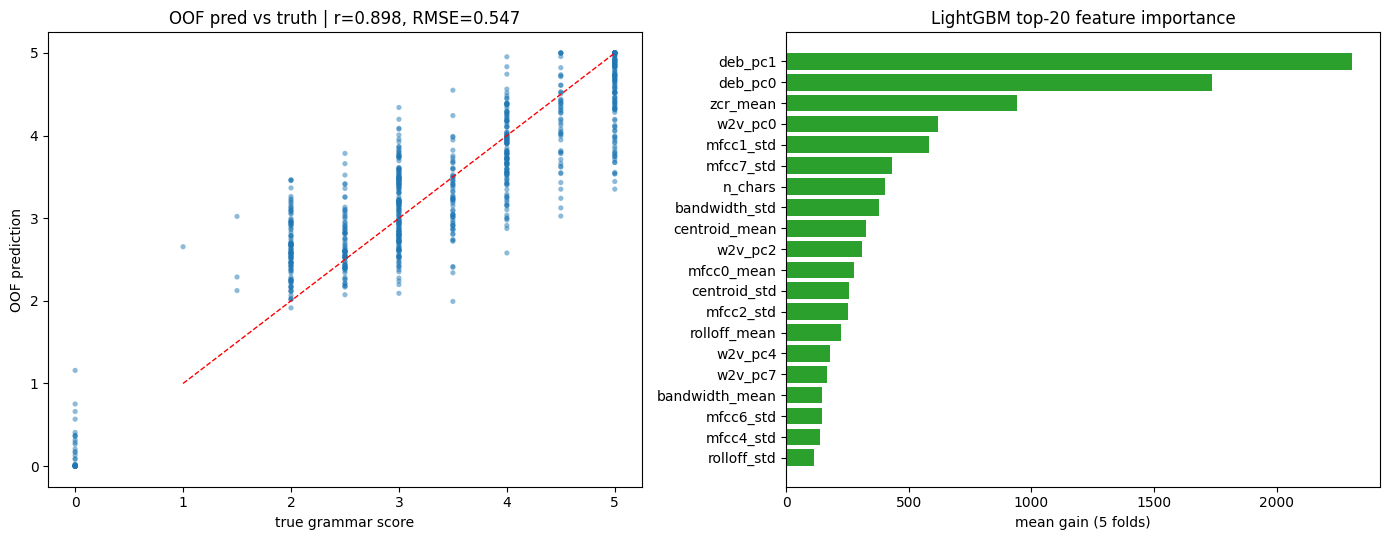

In [13]:
# ---- plots ----
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

ax[0].scatter(y, oof['blend'], s=14, alpha=0.5, edgecolor='none')
ax[0].plot([1, 5], [1, 5], 'r--', lw=1)
ax[0].set(xlabel='true grammar score', ylabel='OOF prediction',
          title=f'OOF pred vs truth | r={pearsonr(y, oof["blend"])[0]:.3f}, RMSE={rmse(y, oof["blend"]):.3f}')

top = np.argsort(imp)[::-1][:20][::-1]
ax[1].barh([TREE_NAMES[j] for j in top], imp[top], color='tab:green')
ax[1].set(xlabel='mean gain (5 folds)', title='LightGBM top-20 feature importance')

plt.tight_layout()
plt.savefig(OUT / 'oof_and_importance.png', dpi=130)
plt.show()

In [14]:
# ---- submission ----
pred_map = dict(zip(test_df['filename'], te['blend']))
id_col, tgt_col = sample_sub.columns[0], sample_sub.columns[1]

sub = sample_sub.copy()
sub[tgt_col] = sub[id_col].map(pred_map)
assert sub[tgt_col].notna().all(), 'ids in sample_submission do not match test.csv'
sub[tgt_col] = sub[tgt_col].clip(*CLIP)

assert list(sub.columns) == list(sample_sub.columns) and len(sub) == len(sample_sub)
sub.to_csv(OUT / 'submission.csv', index=False)

print(sub.head())
print(f'test pred mean/std: {sub[tgt_col].mean():.3f} / {sub[tgt_col].std():.3f} '
      f'| train label mean/std: {y.mean():.3f} / {y.std():.3f}')

AssertionError: ids in sample_submission do not match test.csv